In [ ]:
#For colab 
"""from google.colab import drive
drive.mount('/content/drive')"""

"from google.colab import drive\ndrive.mount('/content/drive')"

In [ ]:
#For colab
#%cd = "/content/drive/MyDrive/DEVZEROCLOUD/MatsuoLabs/Final Assignment/

In [ ]:
#For colab
"""import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")"""

'import os\nfrom pathlib import Path\n\ncurrent_dir = Path(os.getcwd())\nclient_path = current_dir / "telecom" / "Client.csv"\nrecord_path = current_dir / "telecom" / "Record.csv"\n\nfor p in (client_path, record_path):\n    print(f"{\'OK \' if p.exists() else \'MISSING \'} {p}")'

In [ ]:
#For local
client_path = "telecom/Client.csv"
record_path = "telecom/Record.csv"

In [ ]:
!pip install sweetviz

In [ ]:
!pip install pycaret==3.3.2

In [ ]:
!pip install mlflow==2.13.2

In [ ]:
!pip install optuna

In [ ]:
!pip install catboost

# **Final Assigment - Case: Telecom**


---


**What this notebook walks through:**


1.   Introduction and Market Context
2.   EDA
3.   Problem Definition
4.   Feature Engineering
5.   Experiments
6.   Business Impact
7.   Next Steps


## 1. Introduction and Market Context

### 1.1 About the Company
Company A (an anonymous telecommunications service provider) has a large dataset but has limited in-house expertise to utilize them for business. The company hires an IT consulting firm in order to provide, with an association of sales team, a Proof of Concept (PoC).


## 2. Exploratory Data Analysis (EDA)

In [468]:
# Import modules
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score

# ML Al
from sklearn.model_selection import RandomizedSearchCV,RepeatedStratifiedKFold, ShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    classification_report, confusion_matrix
)

features = []

In [469]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


In [470]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
df = df.set_index('Customer_ID')
print(f"Merged: {df.shape}")

Merged: (100000, 99)


In [471]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 1000001 to 1100000
Data columns (total 99 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   rev_Mean          99643 non-null   float64
 1   mou_Mean          99643 non-null   float64
 2   totmrc_Mean       99643 non-null   float64
 3   da_Mean           99643 non-null   float64
 4   ovrmou_Mean       99643 non-null   float64
 5   ovrrev_Mean       99643 non-null   float64
 6   vceovr_Mean       99643 non-null   float64
 7   datovr_Mean       99643 non-null   float64
 8   roam_Mean         99643 non-null   float64
 9   change_mou        99109 non-null   float64
 10  change_rev        99109 non-null   float64
 11  drop_vce_Mean     100000 non-null  float64
 12  drop_dat_Mean     100000 non-null  float64
 13  blck_vce_Mean     100000 non-null  float64
 14  blck_dat_Mean     100000 non-null  float64
 15  unan_vce_Mean     100000 non-null  float64
 16  unan_dat_Mean     

In [472]:
num_cols = df.select_dtypes(include='number').columns

df[num_cols].describe()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,hnd_price,phones,models,truck,rv,lor,adults,income,numbcars,forgntvl,eqpdays
count,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99109.000000,99109.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,97161.000000,97161.000000,97161.000000,99153.000000,99999.000000,99999.000000,98268.000000,98268.000000,69810.000000,76981.000000,74564.000000,50634.000000,98268.000000,99999.000000
mean,58.719985,513.559937,46.179136,0.888828,41.072247,13.559560,13.295062,0.261318,1.286405,-13.933818,-1.021067,5.955085,0.040520,4.022917,0.025777,27.784905,0.029810,144.881677,0.870548,55.085152,0.047590,108.892535,0.774442,1.790838,4.666880,3.683328,29.766550,0.284720,227.763520,1.844036,111.654562,24.753320,28.467865,7.894360,18.193037,88.480285,0.358162,174.080788,0.707832,66.003498,0.416283,165.280703,1.135804,10.044298,145.752225,109.666977,0.011700,1.782928,0.495620,18.833990,1.548140,1.358960,2877.141930,7648.363833,1031.924988,960.111528,7546.314699,2836.366920,57.913832,483.726493,173.554507,519.641210,180.337320,59.193330,509.634576,178.365157,58.683618,101.875763,1.787118,1.545825,0.188820,0.082580,6.177238,2.530326,5.783112,1.567563,0.057974,391.932309
std,46.291677,525.168140,23.623489,2.177619,97.296150,30.500885,30.056089,3.126531,14.711374,276.087509,50.363209,8.954715,0.877136,10.672202,1.490255,38.358734,0.496970,158.267711,9.053901,86.841198,2.127422,118.580079,8.129844,5.315570,12.761953,10.539981,55.833753,1.092101,264.403894,23.733226,162.691285,34.414822,48.962903,16.145590,41.421462,103.066103,4.065630,207.673553,8.410151,91.456885,4.652627,237.332918,17.768683,15.418406,159.348094,119.594305,0.547470,5.353953,0.499983,9.655794,1.075255,0.655555,3790.863474,8666.558293,852.907511,840.170815,8594.889729,3756.513882,36.161292,438.485213,167.824576,533.634073,192.725835,46.695429,496.663453,182.724565,40.758577,61.005671,1.313977,0.898395,0.391368,0.275248,4.735267,1.452819,2.182132,0.625456,0.233696,256.482193
min,-6.167500,0.000000,-26.915000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.740000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,0.000000,0.000000,3.6

In [473]:
df.isnull().sum()

rev_Mean              357
mou_Mean              357
totmrc_Mean           357
da_Mean               357
ovrmou_Mean           357
ovrrev_Mean           357
vceovr_Mean           357
datovr_Mean           357
roam_Mean             357
change_mou            891
change_rev            891
drop_vce_Mean           0
drop_dat_Mean           0
blck_vce_Mean           0
blck_dat_Mean           0
unan_vce_Mean           0
unan_dat_Mean           0
plcd_vce_Mean           0
plcd_dat_Mean           0
recv_vce_Mean           0
recv_sms_Mean           0
comp_vce_Mean           0
comp_dat_Mean           0
custcare_Mean           0
ccrndmou_Mean           0
cc_mou_Mean             0
inonemin_Mean           0
threeway_Mean           0
mou_cvce_Mean           0
mou_cdat_Mean           0
mou_rvce_Mean           0
owylis_vce_Mean         0
mouowylisv_Mean         0
iwylis_vce_Mean         0
mouiwylisv_Mean         0
peak_vce_Mean           0
peak_dat_Mean           0
mou_peav_Mean           0
mou_pead_Mea

Because we detected that there are missing values, we proceed to complete the empty information based on imputations, depending on the type of variable and its impact on the information in the database.

In [474]:
# Usage variables (missing = 0, the client never used that functionality)
usage_fill_zero = [
    "mou_cvce_Mean", "mou_peav_Mean", "mou_opkv_Mean",
    "mou_rvce_Mean", "mouowylisv_Mean", "mouiwylisv_Mean",
    "mou_cdat_Mean", "mou_opkd_Mean", "mou_pead_Mean",
    "avg3mou", "avg6mou", "avg3qty", "avg6qty", "avg3rev", "avg6rev",
    "avgmou", "avgrev", "avgqty",
    "totmou", "adjmou", "totcalls", "adjqty",
    "totrev", "adjrev",
    "plcd_vce_Mean", "attempt_Mean", "complete_Mean",
    "comp_vce_Mean", "peak_vce_Mean", "opk_vce_Mean",
    "recv_vce_Mean", "inonemin_Mean",
    "cc_mou_Mean",
    "owylis_vce_Mean", "iwylis_vce_Mean",
    "drop_vce_Mean", "drop_dat_Mean", "drop_blk_Mean",
    "blck_vce_Mean", "blck_dat_Mean",
    "unan_vce_Mean", "unan_dat_Mean",
    "recv_sms_Mean", "threeway_Mean",
    "callfwdv_Mean", "callwait_Mean",
    "plcd_dat_Mean", "comp_dat_Mean",
    "peak_dat_Mean", "opk_dat_Mean",
    "ccrndmou_Mean", "custcare_Mean",
    "ovrmou_Mean", "ovrrev_Mean", "vceovr_Mean", "datovr_Mean",
    "roam_Mean", "da_Mean",
    "rev_Mean", "mou_Mean", "totmrc_Mean",
    "change_mou", "change_rev",
]
usage_fill_zero = [c for c in usage_fill_zero if c in df.columns]

In [475]:
# Demographic numerical variables → impute with mean
numeric_fill_median = [
    "income", "adults", "numbcars", "lor",
    "hnd_price", "eqpdays", "phones", "models",
    "months", "uniqsubs", "actvsubs",
]
numeric_fill_median = [c for c in numeric_fill_median if c in df.columns]

In [476]:
binary_fill_mode = [
    "truck",
    "rv",
    "ownrent",
    "creditcd",
    "asl_flag",
    "forgntvl",
    "kid0_2", 
    "kid3_5", 
    "kid6_10", 
    "kid11_15", 
    "kid16_17",
]
binary_fill_mode = [c for c in binary_fill_mode if c in df.columns]

In [477]:
# Demographic categorical variables → impute with "Unknown"
unknown_cols = ['ethnic', 'marital', 'prizm_social_one', 
                'HHstatin', 'infobase', 'area']
unknown_fill_unknown = [c for c in unknown_cols if c in df.columns]

In [478]:
# categorical variables → impute with Mode
mode_cols = ['refurb_new', 'dualband', 
             'new_cell', 'dwlltype', 'dwllsize', 'crclscod']

mode_cols_fill_unknown = [c for c in mode_cols if c in df.columns]

In [479]:
#APPLYING IMPUTATIONS
 
# Usage variables → 0
df[usage_fill_zero] = df[usage_fill_zero].fillna(0)

# Demographic numbers → median
for col in numeric_fill_median:
    df[col] = df[col].fillna(df[col].median())

# Binary → mode
for col in binary_fill_mode:
    df[col] = df[col].fillna(df[col].mode()[0])

# Categorical → Unknown
for col in unknown_cols:
    df[col] = df[col].fillna('Unknown')

for col in mode_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['hnd_webcap'] = df['hnd_webcap'].fillna('UNKW')

df['dualband'] = df['dualband'].fillna('U')

# Target → remove nulls
if "churn" in df.columns:
    n_before = len(df)
    df = df.dropna(subset=["churn"])
    print(f"Rows removed due to null churn: {n_before - len(df)}")

Rows removed due to null churn: 0


In [480]:
# Verification
remaining = df.isnull().sum()
remaining = remaining[remaining > 0].sort_values(ascending=False)
 
print(f"\nFinal Shape: {df.shape}")
print(f"Missing total after: {df.isnull().sum().sum()}")
 
if len(remaining) > 0:
    print(f"\nColumns with missing residual ({len(remaining)}):")
    print(remaining.to_string())
else:
    print("\nWithout missing residual values.")


Final Shape: (100000, 99)
Missing total after: 0

Without missing residual values.


In order to provide a overview of each variable, including distribution, descriptive statistics, missing values, unique values, outliers, and relationships with the target variable, I used Sweetviz library. The summary report is generated on "sweetviz.html". 

In [481]:
"""import sweetviz as sv

report = sv.analyze(df)

report.show_html("sweetviz.html")"""

'import sweetviz as sv\n\nreport = sv.analyze(df)\n\nreport.show_html("sweetviz.html")'

---

### Variable Target Definition

**Churn** is the target variable of this project and represents whether a customer has discontinued the telecommunications service during the observation period.

- **0 = Non-Churner (Customer Retained)**
- **1 = Churner (Customer Left the Service)**

This variable was selected as the prediction target because customer churn directly affects revenue, profitability, and customer lifetime value. By identifying customers at risk of leaving, the company can implement proactive retention strategies, reduce customer attrition, and improve long-term business performance.

The objective of the predictive model is to learn patterns from customer behavior, service usage, billing information, and network performance indicators in order to accurately classify customers as churners or non-churners.

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


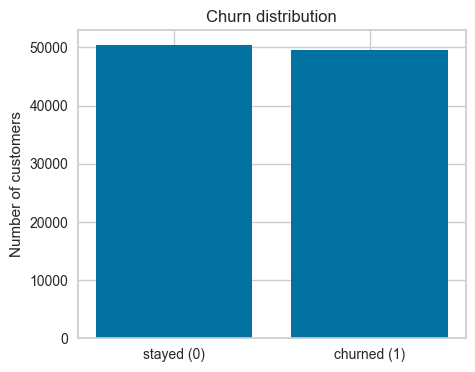

In [482]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))
    
# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

---
In order to get the best features that might predict the churn tendency, the feature selection will based on the correlation information related to the churn variable

In [483]:
def plot_churn_correlations(
    df,
    target="churn",
    top_n=20,
    threshold=0.0,
    figsize=(10, 8)
):
    """
    Displays the correlations of all numerical variables with the target variable (churn), ordered from highest to lowest.

    Parameters:

    df: DataFrame with the data
    target: Name of the target column (default "churn")
    top_n: Number of variables to display (default 20)
    threshold: Show only correlations greater than this value
    figsize: Figure size
    """

    corr = (
        df.select_dtypes(include="number")
          .corr()[target]
          .drop(target)
          .abs()
          .sort_values(ascending=False)
    )

    # Apply filters
    corr = corr[corr >= threshold].head(top_n)

    corr_signed = (
        df.select_dtypes(include="number")
          .corr()[target]
          .drop(target)
          .loc[corr.index]
    )

    # Palette: blue = positive, red = negative
    colors = ["#378ADD" if v > 0 else "#E24B4A" for v in corr_signed]

    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(corr.index, corr_signed, color=colors, height=0.6)

    
    ax.axvline(0, color="black", linewidth=0.8)
    for x in [-0.3, -0.1, 0.1, 0.3]:
        ax.axvline(x, color="gray", linewidth=0.4, linestyle="--", alpha=0.5)

    for bar, val in zip(bars, corr_signed):
        offset = 0.005 if val >= 0 else -0.005
        ha = "left" if val >= 0 else "right"
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", ha=ha, fontsize=9)

    ax.set_xlabel(f"Correlation with '{target}'", fontsize=11)
    ax.set_title(
        f"Top {len(corr)} variables most correlated with '{target}'",
        fontsize=13, fontweight="bold", pad=12
    )
    ax.invert_yaxis()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    from matplotlib.patches import Patch
    legend = [
        Patch(facecolor="#378ADD", label="Positive correlation"),
        Patch(facecolor="#E24B4A", label="Negative correlation"),
    ]
    ax.legend(handles=legend, loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.show()
    return corr_signed


---

### Numerical Feature Analysis

We analyze the numerical variables correlated with churn to identify opportunities for feature engineering.

In [484]:
df_clean = df.copy()

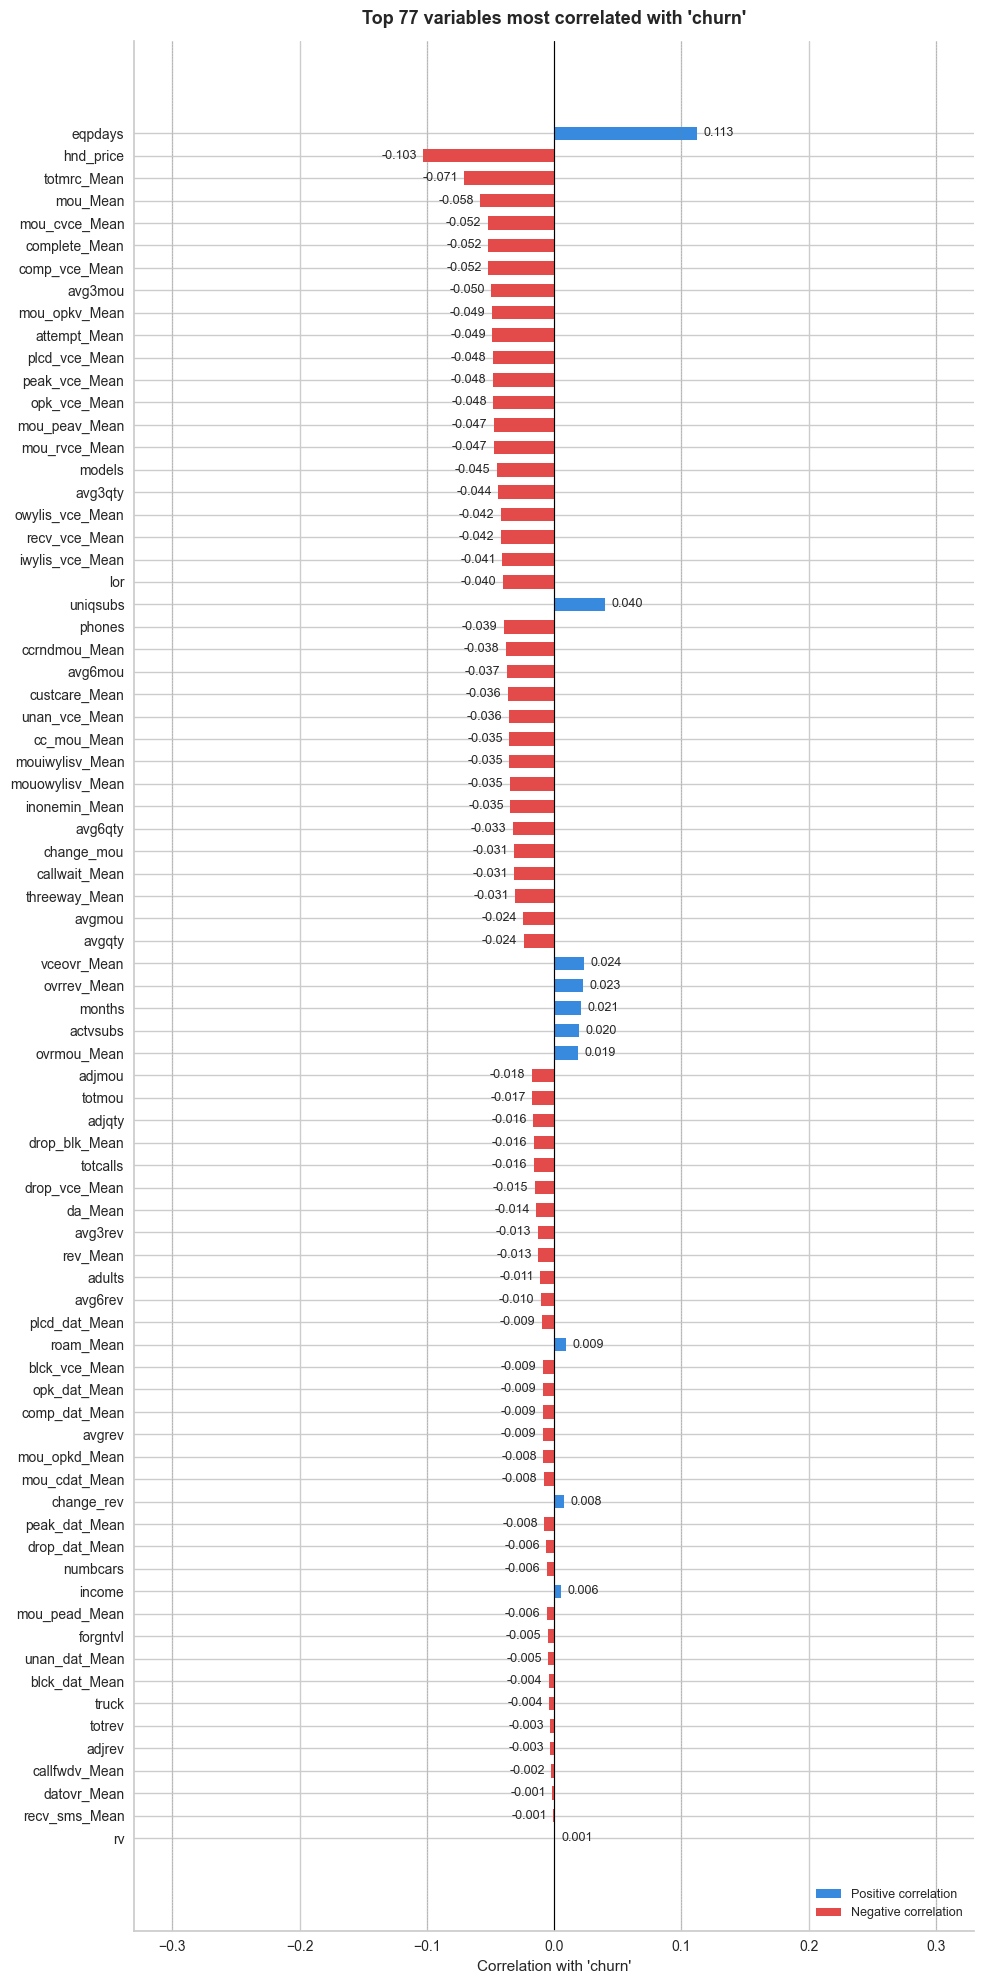

eqpdays            0.112693
hnd_price         -0.102680
totmrc_Mean       -0.070620
mou_Mean          -0.058159
mou_cvce_Mean     -0.052042
complete_Mean     -0.051740
comp_vce_Mean     -0.051574
avg3mou           -0.049546
mou_opkv_Mean     -0.048896
attempt_Mean      -0.048533
plcd_vce_Mean     -0.048321
peak_vce_Mean     -0.048320
opk_vce_Mean      -0.047873
mou_peav_Mean     -0.047287
mou_rvce_Mean     -0.047148
models            -0.045059
avg3qty           -0.043883
owylis_vce_Mean   -0.042065
recv_vce_Mean     -0.041779
iwylis_vce_Mean   -0.040853
lor               -0.040203
uniqsubs           0.039882
phones            -0.039451
ccrndmou_Mean     -0.037890
avg6mou           -0.037358
custcare_Mean     -0.036393
unan_vce_Mean     -0.035560
cc_mou_Mean       -0.035248
mouiwylisv_Mean   -0.035021
mouowylisv_Mean   -0.034914
inonemin_Mean     -0.034506
avg6qty           -0.032585
change_mou        -0.031153
callwait_Mean     -0.031082
threeway_Mean     -0.030657
avgmou            -0

In [485]:
plot_churn_correlations(df, target="churn", figsize=(10,20),top_n=100)

---

#### About the Analysis

The correlation analysis reveals that **no individual numerical feature has a strong linear relationship with churn**. The highest absolute correlation values are observed for **eqpdays** (*r* = 0.113) and **hnd_price** (*r* = -0.103), both of which remain relatively weak.

This suggests that customer churn is likely driven by the **combined effect of multiple factors**, rather than by a single dominant variable. Consequently, feature engineering efforts should focus on creating interaction terms, ratios, aggregated metrics, and behavioral indicators that can capture more complex patterns associated with churn.

Some notable observations include:

- **eqpdays** shows the strongest positive association with churn (*r* = 0.113), indicating that customers with older devices may be slightly more likely to churn.
- **hnd_price** exhibits the strongest negative association (*r* = -0.103), suggesting that customers with more expensive devices tend to be less likely to churn.
- Usage-related variables such as **mou_Mean**, **avg3mou**, **avg6mou**, **totmou**, and **totmrc_Mean** show weak negative correlations, indicating that more engaged customers generally have lower churn rates.
- Subscription-related features such as **phones**, **models**, and **uniqsubs** may contain useful information when combined with other variables, despite their weak individual correlations.
- The generally low correlation values suggest the presence of **non-linear relationships and feature interactions**, making engineered features particularly important for improving predictive performance.

The table below summarizes the correlation coefficients between the numerical variables and the target variable (**churn**).

---


We'll start with the best correlations and look at them in more detail later

In [486]:
features = []

List = ['eqpdays', 'hnd_price', 'months', 'change_mou', 'mou_Mean',
        'totmrc_Mean', 'uniqsubs', 'lor', 'refurb_new', 'avgqty']

for i in List:
    features.append(i)
    
print(features)

['eqpdays', 'hnd_price', 'months', 'change_mou', 'mou_Mean', 'totmrc_Mean', 'uniqsubs', 'lor', 'refurb_new', 'avgqty']



---

#### Relevant Correlations

The variables **eqpdays**, **hnd_price**, and **uniqsubs** show notable relationships with several other features in the dataset:

**Device Age (`eqpdays`)**
- Positive correlation with **months** (*r* = 0.48)
- Negative correlation with **hnd_price** (*r* = -0.47)
- Negative correlation with **models** (*r* = -0.38)
- Negative correlation with **phones** (*r* = -0.36)
- Negative correlation with **avgmou** (*r* = -0.33)
- Negative correlation with **avg3mou** (*r* = -0.31)
- Negative correlation with **avgqty** (*r* = -0.31)

**Handset Price (`hnd_price`)**
- Negative correlation with **months** (*r* = -0.26)
- Positive correlation with **avgmou** (*r* = 0.24)
- Positive correlation with **mou_Mean** (*r* = 0.23)
- Positive correlation with **avg3mou** (*r* = 0.23)

**Number of Unique Subscriptions (`uniqsubs`)**
- Strong positive correlation with **actvsubs** (*r* = 0.77)
- Weak positive correlation with **crclscod** (*r* = 0.27)
- Weak positive correlation with **asl_flag** (*r* = 0.16)


---

### Categorical Feature Analysis

We examine the categorical variables associated with churn to identify patterns that may support the creation of new features.


In [487]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    
    if confusion_matrix.shape[0] < 2 or confusion_matrix.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()

    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Corrección de Bergsma & Wicher
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / max(1e-12, min(kcorr - 1, rcorr - 1)))

In [488]:
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns

cramers_results = pd.DataFrame({
    'Feature': cat_cols,
    'Cramers_V': [
        cramers_v(df_clean[col], df_clean['churn'])
        for col in cat_cols
    ]
}).sort_values('Cramers_V', ascending=False)

cramers_results

,Feature,Cramers_V
7,hnd_webcap,0.088328
1,crclscod,0.077956
2,asl_flag,0.069373
14,ethnic,0.063667
5,dualband,0.053680
4,area,0.050432
6,refurb_new,0.031602
11,infobase,0.029480
10,marital,0.027942
12,HHstatin,0.023519



---

#### Categorical Feature Relationships

The analysis of categorical variables did not reveal any strong direct association with churn. Therefore, potential feature engineering efforts will focus on creating derived variables based on the relationships between categorical features and other relevant customer attributes.

As an initial step, the variables **kid0_2**, **kid3_5**, **kid6_10**, **kid11_15**, and **kid16_17** will be combined into a single indicator representing whether the customer has children. Since these variables capture the presence of children in different age ranges, aggregating them may provide a more informative and less sparse feature.

Several categorical variables also exhibit moderate relationships with numerical features:

**Customer Classification (`crclscod`)**
- Positive correlation with **months** (*r* = 0.63)
- Positive correlation with **eqpdays** (*r* = 0.36)

**Account Status Flag (`asl_flag`)**
- Positive correlation with **months** (*r* = 0.28)
- Positive correlation with **ccrndmou_Mean** (*r* = 0.24)
- Positive correlation with **eqpdays** (*r* = 0.23)

**Web-Capable Handset (`hnd_webcap`)**
- Positive correlation with **hnd_price** (*r* = 0.65)
- Positive correlation with **eqpdays** (*r* = 0.56)
- Positive correlation with **months** (*r* = 0.35)
- Positive correlation with **avgmou** (*r* = 0.24)
- Positive correlation with **mou_Mean** (*r* = 0.22)

**Dual-Band Handset (`dualband`)**
- Positive correlation with **hnd_price** (*r* = 0.34)
- Positive correlation with **eqpdays** (*r* = 0.27)
- Positive correlation with **months** (*r* = 0.18)

---

In [489]:
List = ['crclscod','asl_flag', 'hnd_webcap', 'dualband']

for i in List:
    features.append(i)
    
print(features)

['eqpdays', 'hnd_price', 'months', 'change_mou', 'mou_Mean', 'totmrc_Mean', 'uniqsubs', 'lor', 'refurb_new', 'avgqty', 'crclscod', 'asl_flag', 'hnd_webcap', 'dualband']



---

## 3. Problem Definition

As acquiring new customers is significantly more expensive than retaining existing ones. The loss of customers directly impacts revenue, profitability, and long-term business growth.

The objective of this proof of concept is to develop a predictive model capable of identifying customers who are likely to churn before they discontinue the service. By leveraging customer demographics, service usage patterns, billing information, device characteristics, subscription behavior, or network quality indicators, the model aims to detect early warning signals associated with customer attrition.

---


## 4. Feature Engineering

In [490]:
#Creating new features based on the relations observed

df_clean['eqpdays_hndprice'] = df_clean['eqpdays'] / (df_clean['hnd_price']+ 1)
df_clean['eqpdays_months'] = df_clean['eqpdays'] / (df_clean['months'] + 1)

df_clean['webcap_num'] = df_clean['hnd_webcap'].map({'WCMB': 2, 'WC': 1, 'UNKN': 0}).fillna(0)
df_clean['dual_num'] = df_clean['dualband'].map({'Y': 1, 'T': 1, 'N': 0, 'U': 0}).fillna(0)
df_clean['device_tech_score'] = df_clean['hnd_price'].fillna(0) * (df_clean['webcap_num'] + df_clean['dual_num'] + 1)

df_clean['usage_trend'] = df_clean['change_mou'] + df_clean['change_rev']

df_clean['overage_burden'] = (df_clean['ovrmou_Mean'] / df_clean['mou_Mean'].replace(0, np.nan)).fillna(0)

df_clean['rev_per_mou'] = (df_clean['rev_Mean'] / df_clean['mou_Mean'].replace(0, np.nan)).fillna(0)

df_clean['call_failure_rate'] = ((df_clean['drop_vce_Mean'] + df_clean['blck_vce_Mean']) / df_clean['attempt_Mean'].replace(0, np.nan)).fillna(0)

df_clean['mou_Mean_totmrc_Mean'] = (df_clean['mou_Mean'] / df_clean['totmrc_Mean'].replace(0, np.nan)).fillna(0)

df_clean['avgrev_uniqsubs'] = (df_clean['avgrev'] / df_clean['uniqsubs'].replace(0, np.nan)).fillna(0)

df_clean['hnd_price_eqpdays'] = (df_clean['hnd_price'] / df_clean['eqpdays'].replace(0, np.nan)).fillna(0)

df_clean['complete_Mean_call_failure_rate'] = df_clean['complete_Mean'] * (1 - df_clean['call_failure_rate'])

df_clean['lor_usage_trend'] = df_clean['lor'] * (1 + df_clean['usage_trend'])

kid_cols = ['kid0_2','kid3_5','kid6_10','kid11_15','kid16_17']
df_clean['has_kids'] = df_clean[kid_cols].apply(lambda row: 1 if any(v == 'Y' for v in row) else 0, axis=1)
df_clean['num_kid_groups'] = df_clean[kid_cols].apply(lambda row: sum(v == 'Y' for v in row), axis=1)

In [491]:
List = ['eqpdays_hndprice',
    'eqpdays_months',
    'device_tech_score',
    'usage_trend',
    'overage_burden',
    'rev_per_mou',
    'call_failure_rate',
    'mou_Mean_totmrc_Mean',
    'avgrev_uniqsubs',
    'hnd_price_eqpdays',
    'complete_Mean_call_failure_rate',
    'lor_usage_trend',
]

for i in List:
    features.append(i)

print(features)

['eqpdays', 'hnd_price', 'months', 'change_mou', 'mou_Mean', 'totmrc_Mean', 'uniqsubs', 'lor', 'refurb_new', 'avgqty', 'crclscod', 'asl_flag', 'hnd_webcap', 'dualband', 'eqpdays_hndprice', 'eqpdays_months', 'device_tech_score', 'usage_trend', 'overage_burden', 'rev_per_mou', 'call_failure_rate', 'mou_Mean_totmrc_Mean', 'avgrev_uniqsubs', 'hnd_price_eqpdays', 'complete_Mean_call_failure_rate', 'lor_usage_trend']



---

## 5. Experiments

The experimentation process followed a structured approach consisting of model benchmarking and hyperparameter optimization.

First, the final dataset was constructed using the selected features obtained during the feature engineering and feature selection stages. A classification setup was then created using PyCaret, which provided a standardized environment for data preprocessing, model training, and evaluation. To ensure robust performance estimation, all models were evaluated using **5-fold Stratified Cross-Validation**, preserving the class distribution across folds and reducing the risk of biased results.

Several machine learning algorithms were trained and compared using key classification metrics, with particular emphasis on Recall, F1-Score, ROC-AUC, and PR-AUC due to the business objective of identifying customers at risk of churn.

After selecting the best-performing model, **Optuna** was employed for hyperparameter optimization. Optuna systematically explored the hyperparameter search space to identify configurations that improved predictive performance while maintaining generalization capability. This optimization process enabled the model to achieve better results than the baseline configuration obtained during the initial comparison phase.

This two-stage experimentation framework ensured that the final model was selected based on both its baseline performance and its ability to be further optimized through automated hyperparameter tuning.

The final model selected was **CatBoost** as the most suitable algorithm for the churn prediction task, after which Optuna was used to obtain the final optimized configuration


---

### 5.1 Pycaret Pipeline Model Selection


In [492]:
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = (
        LabelEncoder()
        .fit_transform(df_clean[col].astype(str))
    )

In [493]:
from pycaret.classification import *

s = setup(
    data          = df_clean,
    target        = 'churn',
    train_size    = 0.7,
    fold          = 5,
    fold_strategy = 'stratifiedkfold',
    feature_selection = True,
    feature_selection_method='classic',
    n_features_to_select=0.2,
    n_jobs=-1,
    session_id    = 42,
    verbose       = True,
)

[LightGBM] [Info] Number of positive: 34693, number of negative: 35307
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021641 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17633
[LightGBM] [Info] Number of data points in the train set: 70000, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495614 -> initscore=-0.017543
[LightGBM] [Info] Start training from score -0.017543


,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(100000, 115)"
4,Transformed data shape,"(100000, 23)"
5,Transformed train set shape,"(70000, 23)"
6,Transformed test set shape,"(30000, 23)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


In [ ]:
best_models = compare_models(sort='Recall', n_select=5)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,15:29:44
Status,. . . . . . . . . . . . . . . . . .,Fitting 5 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Decision Tree Classifier


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5804,0.6081,0.5464,0.5818,0.5634,0.1603,0.1606,135.2700
knn,K Neighbors Classifier,0.5499,0.5654,0.5343,0.5471,0.5406,0.0996,0.0996,8.5440
nb,Naive Bayes,0.5361,0.5823,0.2365,0.5790,0.3304,0.0674,0.0835,42.1760


Processing:   0%|          | 0/73 [00:00<?, ?it/s]

In [ ]:
model = best_models[0]

In [ ]:
print(model)

The model comparison conducted using PyCaret identified **CatBoost Classifier** as the best-performing algorithm among the evaluated candidates. CatBoost achieved the following average performance metrics:

- **Accuracy:** 0.6353
- **AUC:** 0.6883
- **Recall:** 0.6414
- **Precision:** 0.6296
- **F1-Score:** 0.6354

---

In [ ]:
X = df_clean[features]
y = df_clean['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)



---

### 5.2 Model Tuning

Hyperparameter optimization was performed using **Optuna** to identify the parameter configuration that yields the best model performance.

In [ ]:
import optuna
from pycaret.classification import get_config
from sklearn.model_selection import cross_val_score
from catboost import CatBoostClassifier


def objective(trial):
    params = {
        'depth':           trial.suggest_int('depth', 4, 10),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'iterations':      trial.suggest_int('iterations', 50, 250),
        'l2_leaf_reg':     trial.suggest_int('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_int('random_strength', 1, 5),
        'border_count':    trial.suggest_categorical('border_count', [32, 64, 128]),
        'random_state': 42,
        'verbose': False,
        'task_type': 'CPU',
    }
    clf = CatBoostClassifier(**params)
    scores = cross_val_score(clf, X_train, y_train, cv=3, scoring='recall', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

KeyboardInterrupt: 

In [ ]:
print("Best Parameters: ", study.best_params)


---

### 5.3 Model Evaluation

After completing the hyperparameter optimization process, the final CatBoost model was trained using the best parameter configuration identified by Optuna. The model was then evaluated to determine its effectiveness in predicting customer churn and to verify whether it met the performance requirements established for the business problem.

To be considered suitable for deployment, the churn prediction model was expected to satisfy the following minimum performance criteria:

| Metric | Minimum Threshold | Rationale |
|----------|----------|----------|
| Recall | ≥ 0.50 | Prioritize the identification of customers at risk of churn. |
| Precision | ≥ 0.50 | Ensure that retention efforts are directed toward genuinely at-risk customers. |
| F1-Score | ≥ 0.50 | Maintain a balance between Recall and Precision. |
| ROC-AUC | ≥ 0.50 | Demonstrate adequate discriminatory power between churners and non-churners. |

In [ ]:
from catboost import CatBoostClassifier
best_params = {
    'depth': 5, 
    'learning_rate': 0.014938499387908432, 
    'iterations': 130, 
    'l2_leaf_reg': 1, 
    'random_strength': 2, 
    'border_count': 128
}

model = CatBoostClassifier(
    **best_params,
    random_state=42,
    task_type='CPU',
    verbose=False
)

In [ ]:
from catboost import CatBoostClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


train_auc_scores, valid_auc_scores = [], []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y_train)):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_valid = X_train.iloc[valid_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_valid = y_train.iloc[valid_idx]

    model.fit(
        X_fold_train, y_fold_train,
        early_stopping_rounds = 50,
        use_best_model      = True,
        eval_set     = (X_fold_valid, y_fold_valid),
    )

    train_auc = roc_auc_score(y_fold_train, model.predict_proba(X_fold_train)[:, 1])
    valid_auc = roc_auc_score(y_fold_valid, model.predict_proba(X_fold_valid)[:, 1])

    train_auc_scores.append(train_auc)
    valid_auc_scores.append(valid_auc)

    print(f"Fold {fold+1} | Train AUC: {round(train_auc,4)} | Valid AUC: {round(valid_auc,4)} | Gap: {round(train_auc-valid_auc,4)}")

print(f"\nAverage Train AUC: {round(np.mean(train_auc_scores), 4)}")
print(f"Average Valid AUC: {round(np.mean(valid_auc_scores), 4)}")
print(f"Average Gap:       {round(np.mean(train_auc_scores) - np.mean(valid_auc_scores), 4)}")

Fold 1 | Train AUC: 0.6565 | Valid AUC: 0.6516 | Gap: 0.0049
Fold 2 | Train AUC: 0.6556 | Valid AUC: 0.6503 | Gap: 0.0053
Fold 3 | Train AUC: 0.6564 | Valid AUC: 0.6501 | Gap: 0.0063
Fold 4 | Train AUC: 0.6544 | Valid AUC: 0.65 | Gap: 0.0044
Fold 5 | Train AUC: 0.6551 | Valid AUC: 0.6545 | Gap: 0.0006

Average Train AUC: 0.6556
Average Valid AUC: 0.6513
Average Gap:       0.0043


In [ ]:
# Final evaluation on the held-out 30%
model.fit(
    X_train, y_train,
    early_stopping_rounds = 50,
    use_best_model      = True,
    eval_set=(X_test, y_test)
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [ ]:
print("Accuracy: ",  round(accuracy_score(y_test,  y_pred), 4))
print("Precision:",  round(precision_score(y_test, y_pred), 4))
print("Recall:   ",  round(recall_score(y_test,    y_pred), 4))
print("F1:       ",  round(f1_score(y_test,        y_pred), 4))
print("ROC AUC:  ",  round(roc_auc_score(y_test,   y_prob), 4))

Accuracy:  0.597
Precision: 0.5766
Recall:    0.7033
F1:        0.6337
ROC AUC:   0.6525


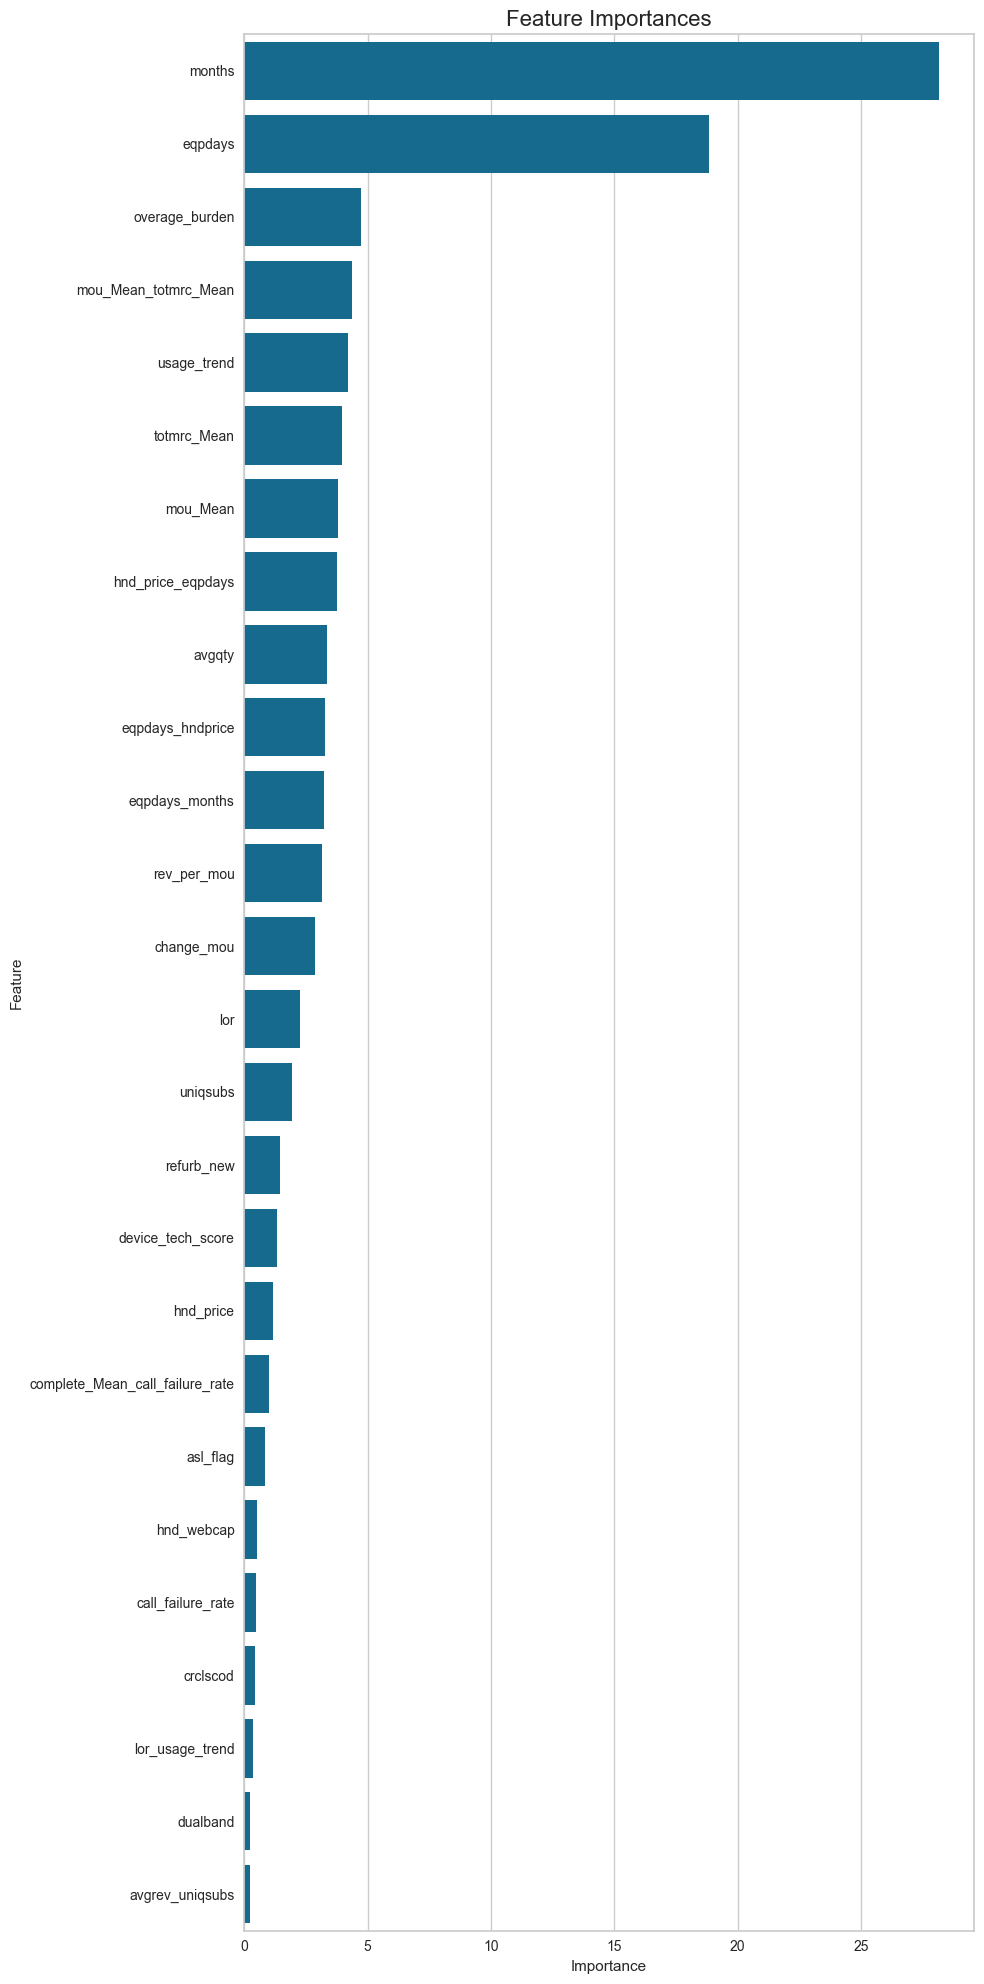

In [ ]:
# Create a DataFrame of features and their importances
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 20))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(feature_importances)

,Feature,Importance
2,months,28.173110
0,eqpdays,18.821168
18,overage_burden,4.730468
21,mou_Mean_totmrc_Mean,4.383965
17,usage_trend,4.216969
5,totmrc_Mean,3.973743
4,mou_Mean,3.790278
23,hnd_price_eqpdays,3.769002
9,avgqty,3.363177
14,eqpdays_hndprice,3.275118


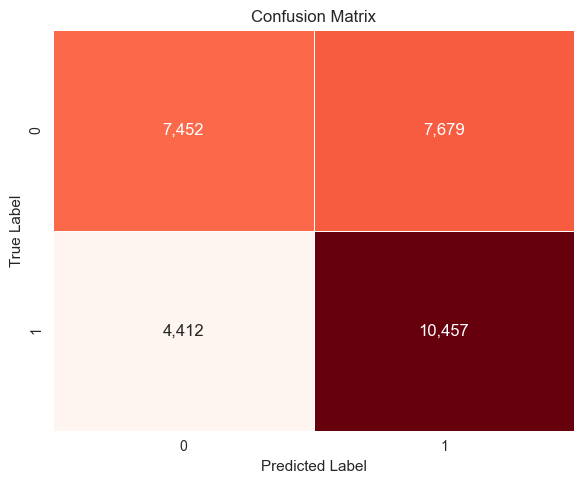

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt=',d',
    cmap='Reds',
    cbar=False,
    linewidths=0.5,
    linecolor='white'
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

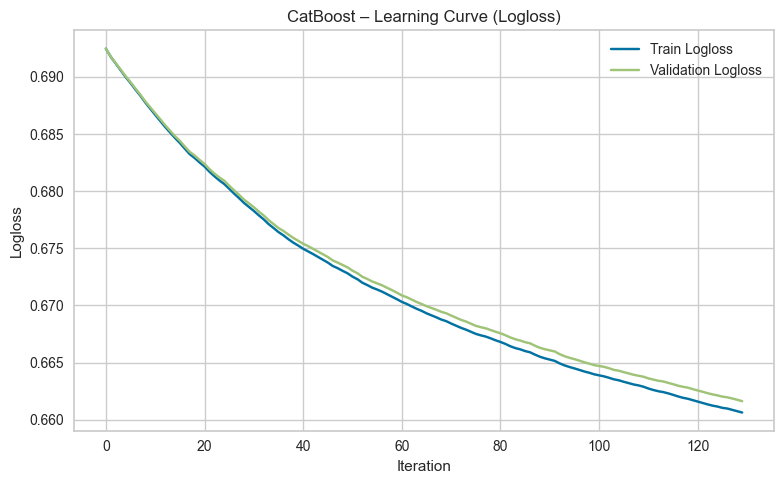

In [ ]:
evals = model.get_evals_result()

learn_keys = list(evals['learn'].keys())
metric_key = 'AUC' if 'AUC' in learn_keys else learn_keys[0]

train_curve = evals['learn'][metric_key]
test_curve  = evals['validation'][metric_key]

plt.figure(figsize=(8, 5))
plt.plot(train_curve, label=f'Train {metric_key}')
plt.plot(test_curve,  label=f'Validation {metric_key}')
plt.xlabel('Iteration')
plt.ylabel(metric_key)
plt.title(f'CatBoost – Learning Curve ({metric_key})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


---

## Business Impact

Business impact analysis evaluates the financial value of the customer churn prediction model by comparing the cost of retention campaigns with the potential losses associated with customer attrition.

By identifying customers most likely to leave, the model allows for a more efficient allocation of retention resources, reducing unnecessary expenses and increasing the return on investment for these campaigns.


---

In [ ]:
from sklearn.metrics import confusion_matrix

# Quantity of real churners capture the model

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
total_churners   = y_test.sum()

print(f"Clients at real risk identified: {tp} of {tp + fn}")

Clients at real risk identified: 10457 of 14869
Cost of unnecessary intervention: 7679 clients


### Decile Analysis: Measuring Business Effectiveness

While traditional evaluation metrics assess overall predictive performance, retention strategies require a more practical perspective. In most business scenarios, only a subset of customers can be targeted due to budget and operational constraints.

By ranking customers according to their predicted churn probability and grouping them into deciles, we can determine how effectively the model identifies high-risk customers. This analysis shows whether churners are concentrated in the top-ranked segments, where retention efforts would be focused.

Ultimately, decile analysis answers the business question:

> **How many churners can be captured if retention actions are applied only to the highest-risk customers?**

A strong concentration of churners in the top deciles indicates that the model can generate substantial business value, even when its overall classification metrics are not exceptionally high.

In [ ]:
test_idx = X.index[X_test.index]

results = pd.DataFrame({
    'churn_real':    y_test.values,
    'prob_churn':    y_prob,
    'rev_Mean':      df_clean.loc[test_idx, 'rev_Mean'].values,
    'months':        df_clean.loc[test_idx, 'months'].values,
    'custcare_Mean': df_clean.loc[test_idx, 'custcare_Mean'].values,
})

results = results.sort_values('prob_churn', ascending=False).reset_index(drop=True)
results['decile'] = pd.qcut(results.index, q=10, labels=range(1, 11))

total_churners = results['churn_real'].sum()

decile_table = (
    results.groupby('decile', observed=True)
    .agg(
        clientes        = ('churn_real', 'count'),
        churners_reales = ('churn_real', 'sum'),
        prob_media      = ('prob_churn', 'mean'),
        arpu_medio      = ('rev_Mean',   'mean'),
        meses_medio     = ('months',     'mean'),
        custcare_medio  = ('custcare_Mean', 'mean'),
    )
    .reset_index()
)

decile_table['churn_rate']         = decile_table['churners_reales'] / decile_table['clientes']
decile_table['pct_churners_capturados'] = decile_table['churners_reales'] / total_churners
decile_table['pct_churners_acumulado']  = decile_table['pct_churners_capturados'].cumsum()

baseline = 1 / 10
decile_table['lift'] = decile_table['pct_churners_capturados'] / baseline

print(decile_table[[
    'decile', 'clients', 'real_chuners', 'churn_rate',
    'pct_churners_captured', 'pct_churners_acumulate',
    'lift', 'prob_mean', 'arpu_mean', 'months_mean', 'custcare_mean'
]].to_string(index=False))

decile  clientes  churners_reales  churn_rate  pct_churners_capturados  pct_churners_acumulado     lift  prob_media  arpu_medio  meses_medio  custcare_medio
     1      3000             2157    0.719000                 0.145067                0.145067 1.450669    0.612483   58.462969    29.436333        1.254000
     2      3000             1939    0.646333                 0.130406                0.275472 1.304055    0.572697   57.264837    29.519333        1.123556
     3      3000             1773    0.591000                 0.119241                0.394714 1.192414    0.556762   59.341279    29.545000        1.092667
     4      3000             1606    0.535333                 0.108010                0.502724 1.080100    0.543062   57.599711    29.458000        1.198444
     5      3000             1499    0.499667                 0.100814                0.603538 1.008138    0.529350   57.110917    29.459667        1.075000
     6      3000             1428    0.476000             

### Interpretation of Results

The **first decile** (the 10% of customers with the highest predicted churn probability) shows an actual churn rate of **71.9%**, compared with **49.6%** for the overall dataset. In practical terms, this means that by contacting only this top-risk segment, nearly **3 out of every 4 contacted customers are true churners**.

The **lift of 1.45×** in the first decile indicates that the model is **45% more effective than random customer selection**. By targeting only the **top 30% of customers** (deciles 1–3), the company can capture **39.5% of all churners** while incurring less than one-third of the cost of a broad, untargeted retention campaign.

From the **sixth decile onward**, the lift falls below 1, meaning that contacting customers in these lower-risk segments is no longer more effective than random selection. This provides a **natural cutoff threshold** for defining the retention campaign target group.

These results demonstrate that the model can substantially improve the efficiency of retention campaigns by focusing resources on the customers most likely to leave.

---


### Revenue at Risk

Rather than estimating recoverable revenue through external assumptions, the model quantifies the **revenue already at risk** using only historical information available in the dataset, including **monthly revenue (`rev_Mean`)**, **total revenue (`totrev`)**, and **customer tenure (`months`)**.

The rationale is straightforward: customers identified as **high-confidence churners** (those concentrated in the highest-risk deciles) have measurable revenue contributions and documented spending histories. By aggregating these values, we can estimate the financial exposure associated with customer churn and quantify the potential cost of inaction.

This approach provides a data-driven assessment of business risk without relying on assumptions regarding retention success rates, campaign effectiveness, or intervention costs.

To further understand the sources of revenue risk, high-risk churners are segmented according to the model's most discriminative features, including:

- **usage_trend** – changes in customer usage behavior over time.
- **change_mou** – variation in minutes of use.
- **eqpdays** – device age.
- **lor** – length of customer relationship.

This segmentation not only identifies **how much revenue is at risk**, but also reveals **which customer profiles contribute most to that risk**.

In [ ]:
import pandas as pd
import numpy as np

results = pd.DataFrame(X_test.values, columns=X_test.columns)
results['churn_real'] = y_test.values
results['prob_churn'] = y_prob

test_idx = X.index[X_test.index]
results['rev_Mean'] = df_clean.loc[test_idx, 'rev_Mean'].values
results['totrev']   = df_clean.loc[test_idx, 'totrev'].values
results['months']   = df_clean.loc[test_idx, 'months'].values


results_sorted = results.sort_values('prob_churn', ascending=False).reset_index(drop=True)
results_sorted['decile'] = pd.qcut(results_sorted.index, q=10, labels=range(1, 11))

In [ ]:
total_churners = results_sorted['churn_real'].sum()

decile_impact = (
    results_sorted.groupby('decile', observed=True)
    .agg(
        customers              = ('churn_real', 'count'),
        actual_churners        = ('churn_real', 'sum'),
        avg_churn_probability  = ('prob_churn', 'mean'),
        avg_arpu               = ('rev_Mean', 'mean'),
        monthly_revenue_at_risk = ('rev_Mean', 'sum'),
        historical_revenue      = ('totrev', 'sum'),
    )
    .reset_index()
)

decile_impact['churn_rate'] = (
    decile_impact['actual_churners'] / decile_impact['customers']
)

decile_impact['cumulative_pct_churners'] = (
    decile_impact['actual_churners'] / total_churners
).cumsum()

# Monthly revenue at risk from actual churners within each decile (customers correctly identified as being at risk of churn)
decile_impact['monthly_revenue_churners'] = (
    results_sorted[results_sorted['churn_real'] == 1]
    .groupby('decile', observed=True)['rev_Mean']
    .sum()
    .values
)

print(decile_impact[[
    'decile', 'customers', 'actual_churners', 'churn_rate',
    'avg_arpu', 'monthly_revenue_churners', 'historical_revenue',
    'cumulative_pct_churners'
]].to_string(index=False))

decile  clientes  churners_reales  churn_rate  arpu_medio  rev_mensual_churners  revenue_historico  pct_churners_acumulado
     1      3000             2157    0.719000   58.462969         125205.696667         4821604.80                0.145067
     2      3000             1939    0.646333   57.264837         111016.954167         4726628.97                0.275472
     3      3000             1773    0.591000   59.341279         103326.716667         4873642.45                0.394714
     4      3000             1606    0.535333   57.599711          92902.885833         4693399.48                0.502724
     5      3000             1499    0.499667   57.110917          87627.871667         4769142.71                0.603538
     6      3000             1428    0.476000   58.554383          83164.530000         4770723.56                0.699576
     7      3000             1454    0.484667   58.263834          84155.912500         4809303.98                0.797364
     8      3000

In [ ]:
# Focus only on Deciles 1 and 2, where the model has the highest predictive power
high_risk = results_sorted[
    (results_sorted['decile'].isin([1, 2])) &
    (results_sorted['churn_real'] == 1)      # confirmed churners only
].copy()

cluster_features = [
    'usage_trend',
    'change_mou',
    'eqpdays',
    'hnd_price',
    'lor',
    'mou_Mean',
    'call_failure_rate',
    'rev_per_mou',
]

scaler = StandardScaler()
X_clust = scaler.fit_transform(high_risk[cluster_features].fillna(0))

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
high_risk['segment'] = kmeans.fit_predict(X_clust)

In [ ]:
segment_impact = (
    high_risk.groupby('segment')
    .agg(
        churners              = ('churn_real', 'count'),
        avg_churn_probability = ('prob_churn', 'mean'),
        avg_arpu              = ('rev_Mean', 'mean'),
        total_monthly_revenue = ('rev_Mean', 'sum'),      # Monthly revenue at risk
        historical_revenue    = ('totrev', 'sum'),        # Cumulative revenue generated
        avg_tenure_months     = ('months', 'mean'),       # Average customer tenure
        avg_usage_trend       = ('usage_trend', 'mean'),
        avg_change_mou        = ('change_mou', 'mean'),
        avg_eqpdays           = ('eqpdays', 'mean'),
        avg_lor               = ('lor', 'mean'),
    )
    .reset_index()
)

# Mid-term revenue estimate: Average monthly revenue × average tenure, it represents the value these customers historically contributed
segment_impact['mid_term_revenue'] = (
    segment_impact['avg_arpu'] * segment_impact['avg_tenure_months']
)

segment_impact['pct_total_revenue'] = (
    segment_impact['total_monthly_revenue'] / segment_impact['total_monthly_revenue'].sum()
)

print(segment_impact[[
    'segment', 'churners', 'avg_arpu', 'avg_tenure_months',
    'total_monthly_revenue', 'historical_revenue', 'mid_term_revenue',
    'pct_total_revenue', 'avg_usage_trend', 'avg_change_mou',
    'avg_eqpdays', 'avg_lor'
]].round(2).to_string(index=False))

 segment  churners  arpu_medio  meses_promedio  revenue_mensual_total  revenue_historico  revenue_medio_plazo  pct_revenue_total  usage_trend_medio  change_mou_medio  eqpdays_medio  lor_medio
       0       752       60.26           29.53               45311.90         1239881.53              1779.37               0.19            -430.34           -396.27         428.53       5.59
       1      2003       56.53           29.42              113226.17         3104433.62              1662.94               0.48              -9.89            -12.37         369.72       4.94
       2      1341       57.93           29.34               77684.59         2124303.45              1699.59               0.33             -39.76            -38.17         770.25       5.00


In [ ]:
top2_churners = high_risk.shape[0]
top2_monthly_revenue = high_risk['rev_Mean'].sum()
total_monthly_revenue = results_sorted[results_sorted['churn_real'] == 1]['rev_Mean'].sum()

print("── Monthly Revenue at Risk ───────────────────────────────")
print(f"  Churners in Deciles 1-2 (High Confidence):  {top2_churners:,}")
print(f"  Monthly Revenue Represented:                ${top2_monthly_revenue:,.0f}")
print(f"  As % of Total Revenue at Risk:              {top2_monthly_revenue/total_monthly_revenue:.1%}")
print()
print("── Model Context ─────────────────────────────────────────")
print(f"  Total Churners in Test Set:                 {int(total_churners):,}")
print(f"  Total Monthly Revenue at Risk:              ${total_monthly_revenue:,.0f}")
print(f"  Average Churner ARPU:                       ${results_sorted[results_sorted['churn_real']==1]['rev_Mean'].mean():.2f}")

── Revenue mensual en riesgo ───────────────────────────────
  Churners en deciles 1-2 (alta confianza):  4,096
  Revenue mensual que representan:           $236,223
  Como % del revenue total en riesgo:        27.5%

── Contexto del modelo ─────────────────────────────────────
  Total churners en test set:                14,869
  Revenue mensual total en riesgo:           $857,718
  ARPU medio de churners:                    $57.68


### Interpretation of Results

The model identifies **4,096 high-confidence churners** within the first two deciles, representing approximately **$236,223 in monthly revenue at risk**. This corresponds to **27.5% of the total churn-related revenue exposure**, concentrated within only **20% of the customer base**.

Across the entire test set, there are **14,869 actual churners**, with an average monthly revenue (**ARPU**) of **$57.68**, generating a combined monthly revenue of approximately **$857,718**. Without a predictive model, this at-risk population remains indistinguishable from the rest of the customer base, making it difficult to prioritize retention efforts effectively.

The business value of the model lies in its ability to **focus attention on the customers who represent the highest concentration of revenue risk**. Rather than applying costly retention actions across the entire customer population, organizations can target the highest-risk segments identified by the model and allocate resources more efficiently.


---

## Next Steps

Although the final CatBoost model achieve a stronger Recall  above 80%, indicating an ability to identify customers at risk of churn.


Many selected variables showed negligible SHAP importance. Future iterations should evaluate whether these features can be removed or replaced with more informative variables, potentially reducing model complexity and improving interpretability.

Additional experimentation could be conducted using ensemble and statistical approaches, such as:
- XGBoost
- LightGBM